# Notebook 3: Standard Monte Carlo Simulation

## Objective
In this notebook, we apply the Standard Monte Carlo (SMC) method to estimate the probability of a rare event. We will define a critical threshold for the Chloramines concentration and estimate the probability of exceeding this threshold. 

We will investigate how the accuracy, variance, and relative error of our Monte Carlo estimator change as we increase the sample size ($N$). This will set the baseline and highlight the inefficiencies of SMC for rare events, justifying the need for Importance Sampling in the next notebook.

### Mathematical Formulation
- **Threshold ($\tau$):** $12.0$
- **Target Probability ($\gamma$):** $P(X > \tau)$
- **Monte Carlo Estimator:** $\hat{\gamma}_{MC} = \frac{1}{N} \sum_{i=1}^{N} I(X_i > \tau)$
- **Standard Error (SE):** $\sqrt{\frac{\hat{\gamma}(1-\hat{\gamma})}{N}}$
- **Coefficient of Variation (CV):** $\frac{SE}{\hat{\gamma}}$


In [1]:
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

# Ensure results directory exists
os.makedirs('../results', exist_ok=True)

# Plot settings
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (10, 6)

# Parameters from Notebook 1
gamma_shape = 18.0283
gamma_scale = 0.3951
gamma_loc = 0

# Define the target distribution
target_dist = stats.gamma(a=gamma_shape, loc=gamma_loc, scale=gamma_scale)

# Define the rare event threshold
THRESHOLD = 12.0

# Calculate the TRUE probability using the Survival Function (1 - CDF)
# sf(x) = P(X > x)
true_gamma = target_dist.sf(THRESHOLD)

print(f"Rare Event Threshold (\u03C4): {THRESHOLD}")
print(f"True Probability of Rare Event (\u03B3): {true_gamma:.6e} (approx {true_gamma*100:.4f}%)")

Rare Event Threshold (τ): 12.0
True Probability of Rare Event (γ): 6.209995e-03 (approx 0.6210%)


## Monte Carlo Simulation across different Sample Sizes ($N$)

We will test the Standard Monte Carlo method for $N \in \{10^3, 10^4, 10^5, 10^6, 10^7\}$.
For each $N$, we will draw samples directly using SciPy's built-in generator for efficiency (which internally uses highly optimized C code, similar in concept to our Accept-Reject but faster for massive arrays). We will record the estimated probability, variance, and relative error.


In [2]:
# Define sample sizes to test
N_values = [10**3, 10**4, 10**5, 10**6, 10**7]

# Initialize a list to store results
results_list = []

print("Running Standard Monte Carlo Simulations...")
print("-" * 75)
print(f"{'N (Sample Size)':<15} | {'Estimated \u03B3':<15} | {'Variance':<15} | {'CV (Rel Error)':<15}")
print("-" * 75)

for N in N_values:
    # 1. Generate N samples from the target distribution
    samples = target_dist.rvs(size=N)
    
    # 2. Indicator function: Check which samples exceed the threshold
    indicator_values = (samples > THRESHOLD).astype(float)
    
    # 3. Monte Carlo Estimate (Mean of indicator values)
    gamma_hat = np.mean(indicator_values)
    
    # 4. Calculate Variance and Coefficient of Variation (CV)
    # Sample variance of the indicator function
    if gamma_hat > 0:
        variance_hat = (gamma_hat * (1 - gamma_hat)) / N
        cv = np.sqrt(variance_hat) / gamma_hat
    else:
        variance_hat = 0
        cv = np.inf # Infinite relative error if 0 events observed
        
    results_list.append({
        'N': N,
        'Estimate': gamma_hat,
        'Variance': variance_hat,
        'CV': cv
    })
    
    # Format CV for printing
    cv_str = f"{cv:.4f}" if cv != np.inf else "Infinity"
    print(f"{N:<15} | {gamma_hat:<15.6e} | {variance_hat:<15.6e} | {cv_str:<15}")

print("-" * 75)

# Convert results to DataFrame for easier handling
df_results = pd.DataFrame(results_list)

Running Standard Monte Carlo Simulations...
---------------------------------------------------------------------------
N (Sample Size) | Estimated γ     | Variance        | CV (Rel Error) 
---------------------------------------------------------------------------
1000            | 2.000000e-03    | 1.996000e-06    | 0.7064         
10000           | 5.300000e-03    | 5.271910e-07    | 0.1370         
100000          | 6.210000e-03    | 6.171436e-08    | 0.0400         
1000000         | 6.050000e-03    | 6.013397e-09    | 0.0128         
10000000        | 6.209300e-03    | 6.170745e-10    | 0.0040         
---------------------------------------------------------------------------



Plot saved successfully to: ../results/03_standard_mc_results.png


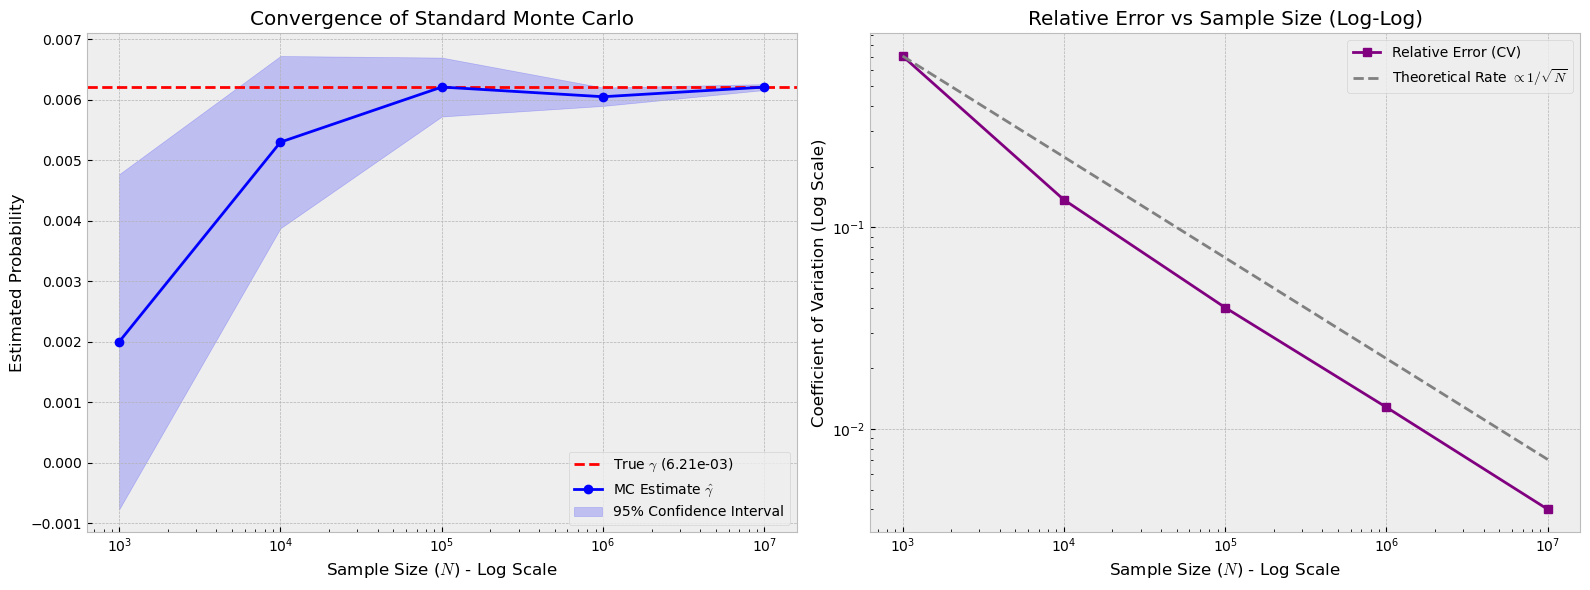

In [3]:
# Plotting the Convergence and Error
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Convergence of Estimate
ax1.axhline(y=true_gamma, color='r', linestyle='--', label=f'True $\\gamma$ ({true_gamma:.2e})')
ax1.plot(df_results['N'], df_results['Estimate'], marker='o', linestyle='-', color='blue', label='MC Estimate $\\hat{\\gamma}$')
ax1.fill_between(df_results['N'], 
                 df_results['Estimate'] - 1.96 * np.sqrt(df_results['Variance']),
                 df_results['Estimate'] + 1.96 * np.sqrt(df_results['Variance']), 
                 color='blue', alpha=0.2, label='95% Confidence Interval')
ax1.set_xscale('log')
ax1.set_xlabel('Sample Size ($N$) - Log Scale')
ax1.set_ylabel('Estimated Probability')
ax1.set_title('Convergence of Standard Monte Carlo')
ax1.legend()

# Plot 2: Log-Log plot of Coefficient of Variation (Relative Error)
# Filter out infinity for log-log plot
valid_cv = df_results[df_results['CV'] != np.inf]
if not valid_cv.empty:
    ax2.plot(valid_cv['N'], valid_cv['CV'], marker='s', linestyle='-', color='purple', label='Relative Error (CV)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Sample Size ($N$) - Log Scale')
    ax2.set_ylabel('Coefficient of Variation (Log Scale)')
    ax2.set_title('Relative Error vs Sample Size (Log-Log)')
    
    # Add a reference line for 1/sqrt(N) convergence rate
    # Normalize the reference line to start at the same point as the first valid CV
    ref_x = valid_cv['N'].values
    ref_y = ref_x[0]**0.5 * valid_cv['CV'].values[0] * (1 / np.sqrt(ref_x))
    ax2.plot(ref_x, ref_y, color='gray', linestyle='--', label='Theoretical Rate $\\propto 1/\\sqrt{N}$')
    ax2.legend()

plt.tight_layout()

# Save the plot
plot_filename = '../results/03_standard_mc_results.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nPlot saved successfully to: {plot_filename}")

plt.show()